## Neural Networks - Deep Learning
**Theodora Tzina - AEM: 10715**
### Exercise 2
#### ***Part C: Optimization of best SVMs***

In [40]:
import time
import numpy as np
import matplotlib.pyplot as plt
import dataProccessing as dp
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

**CIFAR-10 dataset preparation**

Histogram of Oriented Gradients (HOG) was added to improve edge (shape) detection:

In [30]:
# 1. Load CIFAR-10 dataset
x_train_raw, y_train_raw, x_test_raw, y_test_raw = dp.load_cifar10()

# 2. Convert CIFAR-10 labels to binary (Animals vs Vehicles)
y_train_bin, y_test_bin = dp.convert_labels(y_train_raw, y_test_raw)

# 3. Split training data into training and validation sets
x_train_split, y_train_split, x_val_split, y_val_split = dp.split_train_validation(x_train_raw, y_train_bin, val_size=0.4)

# 4. Balance CIFAR-10 dataset by undersampling majority class
x_train_bal, y_train_bal = dp.balance_dataset(x_train_split, y_train_split)

# 5. Extract HOG features from images
x_train_hog = dp.extract_hog_features(x_train_bal)
x_val_hog = dp.extract_hog_features(x_val_split)
x_test_hog = dp.extract_hog_features(x_test_raw)

# 6. Scale features to have zero mean and unit variance
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train_hog)
x_val = scaler.transform(x_val_hog)
x_test = scaler.transform(x_test_hog)

# 7. Rename variables for clarity
y_train = y_train_bal
y_val = y_val_split
y_test = y_test_bin

Loading CIFAR-10 dataset
Original training data shape: (50000, 32, 32, 3)
Original test data shape: (10000, 32, 32, 3)
Flatten training labels shape: (50000,)
Flatten test labels shape: (10000,)

Converting CIFAR-10 labels to binary (Animals vs Vehicles)
CIFAR-10 binary super-classes:
0: Animals (bird, cat, deer, dog, frog, horse)
1: Vehicles (airplane, automobile, ship, truck)
Sample of converted training labels: [0 1 1 0 1 1 0 0 1 0]
Sample of converted test labels: [0 1 1 1 0 0 1 0 0 1]

Splitting training set into training (60.0%) and validation (40.0%)
New training data shape: (30000, 32, 32, 3)
Validation data shape: (20000, 32, 32, 3)

Balancing CIFAR-10 dataset by undersampling majority class
Class 0 samples before balancing: 18000
Class 1 samples before balancing: 12000
Balanced dataset size: 24000 samples
Class 0 samples: 12000
Class 1 samples: 12000

Extracting HOG features from images
HOG features shape: (24000, 324)

Extracting HOG features from images
HOG features shape: 

##### ***RBF Kernel using HOG***
Optimizing RBF Kernel SVM for C=100.0 and gamma=0.001:

In [3]:
# Experiment 1: RBF Kernel with C=100.0 and gamma=0.001
print("\nRunning Experiment 1: RBF Kernel SVM for C=100.0 and gamma=0.001")
print("="*70)

start_time = time.time()

# Train RBF SVM
svm_rbf = SVC(kernel='rbf', C=100.0, gamma=0.001, random_state=42)
svm_rbf.fit(x_train, y_train)
training_time = time.time() - start_time
print(f"\nTraining time: {training_time:.2f} seconds")

# Evaluate RBF SVM on training set
y_train_pred = svm_rbf.predict(x_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.2%}")

# Evaluate RBF SVM on validation set
y_val_pred = svm_rbf.predict(x_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy:.2%}")

print("\n" + "="*70)


Running Experiment 1: RBF Kernel SVM for C=100.0 and gamma=0.001

Training time: 758.91 seconds
Training Accuracy: 100.00%
Validation Accuracy: 88.83%



##### ***RBF Kernel using HOG***
Optimizing RBF Kernel SVM for C=1.0 and gamma='scale':

In [4]:
# Experiment 2: RBF Kernel with C=1.0 and gamma='scale'
print("\nRunning Experiment 2: RBF Kernel SVM for C=1.0 and gamma='scale'")
print("="*70)

start_time = time.time()

# Train RBF SVM
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(x_train, y_train)
training_time = time.time() - start_time
print(f"\nTraining time: {training_time:.2f} seconds")

# Evaluate RBF SVM on training set
y_train_pred = svm_rbf.predict(x_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.2%}")

# Evaluate RBF SVM on validation set
y_val_pred = svm_rbf.predict(x_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy:.2%}")

print("\n" + "="*70)


Running Experiment 2: RBF Kernel SVM for C=1.0 and gamma='scale'

Training time: 115.20 seconds
Training Accuracy: 95.88%
Validation Accuracy: 90.14%



##### ***RBF Kernel using HOG***
Optimizing RBF Kernel SVM for C=10.0 and gamma='scale':

In [5]:
# Experiment 3: RBF Kernel with C=10.0 and gamma='scale'
print("\nRunning Experiment 3: RBF Kernel SVM for C=10.0 and gamma='scale'")
print("="*70)

start_time = time.time()

# Train RBF SVM
svm_rbf = SVC(kernel='rbf', C=10.0, gamma='scale', random_state=42)
svm_rbf.fit(x_train, y_train)
training_time = time.time() - start_time
print(f"\nTraining time: {training_time:.2f} seconds")

# Evaluate RBF SVM on training set
y_train_pred = svm_rbf.predict(x_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.2%}")

# Evaluate RBF SVM on validation set
y_val_pred = svm_rbf.predict(x_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy:.2%}")

print("\n" + "="*70)


Running Experiment 3: RBF Kernel SVM for C=10.0 and gamma='scale'

Training time: 461.31 seconds
Training Accuracy: 100.00%
Validation Accuracy: 90.34%



##### ***Data Augmentation***
Augmenting training dataset with Horizontal Flipping:

In [31]:
# Augmenting training data with Horizontal Flipping
print("\nAugmenting training data with Horizontal Flipping")
print("="*70)

# Flip training images horizontally
x_train_flipped = np.flip(x_train_bal, axis=2)

# Combine original and flipped images
x_train_augmented = np.concatenate((x_train_bal, x_train_flipped), axis=0)
y_train_augmented = np.concatenate((y_train_bal, y_train_bal), axis=0)

print(f"Original training set size: {x_train_bal.shape[0]}")
print(f"Augmented training set size: {x_train_augmented.shape[0]}")
print("="*70 + "\n")

# Complete data processing for augmented training set
x_train_hog = dp.extract_hog_features(x_train_augmented)
x_train = scaler.fit_transform(x_train_hog)
y_train = y_train_augmented


Augmenting training data with Horizontal Flipping
Original training set size: 24000
Augmented training set size: 48000

Extracting HOG features from images
HOG features shape: (48000, 324)



##### ***RBF Kernel using HOG + Augmentation***
Optimizing RBF Kernel SVM for C=10.0 and gamma='scale':

In [11]:
# Experiment 4: RBF Kernel with C=10.0 and gamma='scale'
print("\nRunning Experiment 4: RBF Kernel SVM for C=10.0 and gamma='scale'")
print("="*70)

start_time = time.time()

# Train RBF SVM
svm_rbf = SVC(kernel='rbf', C=10.0, gamma='scale', random_state=42)
svm_rbf.fit(x_train, y_train)
training_time = time.time() - start_time
print(f"\nTraining time: {training_time:.2f} seconds")

# Evaluate RBF SVM on training set
y_train_pred = svm_rbf.predict(x_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.2%}")

# Evaluate RBF SVM on validation set
y_val_pred = svm_rbf.predict(x_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy:.2%}")

print("\n" + "="*70)


Running Experiment 4: RBF Kernel SVM for C=10.0 and gamma='scale'

Training time: 1729.99 seconds
Training Accuracy: 100.00%
Validation Accuracy: 90.75%



##### ***RBF Kernel using HOG + Augmentation***
Optimizing RBF Kernel SVM for C=1.0 and gamma='scale':

In [20]:
# Experiment 5: RBF Kernel with C=1.0 and gamma='scale'
print("\nRunning Experiment 5: RBF Kernel SVM for C=1.0 and gamma='scale'")
print("="*70)

start_time = time.time()

# Train RBF SVM
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(x_train, y_train)
training_time = time.time() - start_time
print(f"\nTraining time: {training_time:.2f} seconds")

# Evaluate RBF SVM on training set
y_train_pred = svm_rbf.predict(x_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.2%}")

# Evaluate RBF SVM on validation set
y_val_pred = svm_rbf.predict(x_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy:.2%}")

print("\n" + "="*70)


Running Experiment 5: RBF Kernel SVM for C=1.0 and gamma='scale'

Training time: 364.69 seconds
Training Accuracy: 95.67%
Validation Accuracy: 90.72%



##### ***Color Histogram Features***
Extracting Color histogram features from images and combining them with HOG features:

In [32]:
# Extract Color Histogram features
x_train_color = dp.extract_color_features(x_train_augmented)
x_val_color = dp.extract_color_features(x_val_split)
x_test_color = dp.extract_color_features(x_test_raw)

# Combine HOG and Color Histogram features
x_train_combined = np.hstack((x_train_hog, x_train_color))
x_val_combined = np.hstack((x_val_hog, x_val_color))
x_test_combined = np.hstack((x_test_hog, x_test_color))

print(f"---> Final Feature Count: {x_train_combined.shape[1]}\n")

# Scale combined features
x_train = scaler.fit_transform(x_train_combined)
x_val = scaler.transform(x_val_combined)
x_test = scaler.transform(x_test_combined)

Extracting Color histogram features from images
Color histogram features shape: (48000, 96)

Extracting Color histogram features from images
Color histogram features shape: (20000, 96)

Extracting Color histogram features from images
Color histogram features shape: (10000, 96)

---> Final Feature Count: 420



##### ***RBF Kernel using HOG + Augmentation + Color Histogram***

Optimizing RBF Kernel SVM for C=1.0 and gamma='scale':

In [ ]:
# Experiment 6: RBF Kernel with C=1.0 and gamma='scale'
print("\nRunning Experiment 6: RBF Kernel SVM for C=1.0 and gamma='scale'")
print("="*70)

start_time = time.time()

# Train RBF SVM
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(x_train, y_train)
training_time = time.time() - start_time
print(f"\nTraining time: {training_time:.2f} seconds")

# Evaluate RBF SVM on training set
y_train_pred = svm_rbf.predict(x_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.2%}")

# Evaluate RBF SVM on validation set
y_val_pred = svm_rbf.predict(x_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy:.2%}")

print("\n" + "="*70)


Running Experiment 6: RBF Kernel SVM for C=1.0 and gamma='scale'

Training time: 532.73 seconds
Training Accuracy: 97.08%
Validation Accuracy: 92.28%



##### ***Support Vectors***
Calculating support vectors ratio for the final model to ensure overfitting is being minimized:

In [39]:
# Calculate support vectors ratio
num_sv = svm_rbf.support_vectors_.shape[0]
num_train = x_train.shape[0]
ratio = num_sv / num_train

print("="*70)
print(f"Total Support Vectors: {num_sv}")
print(f"Training Samples: {num_train}")
print(f"Support Vectors Ratio: {ratio:.2%}")
print("="*70)

if ratio > 0.6:
    print("Warning: High number of Support Vectors ---> Possible Overfitting")
else:
    print("The model generalizes well")

Total Support Vectors: 15037
Training Samples: 48000
Support Vectors Ratio: 31.33%
The model generalizes well


##### ***Final Test Set Evaluation***
Evaluating test set using RBF Kernel SVM using HOG, Augmentation and Color features (C=1.0, gamma='scale'):


Final Evaluation on Test Set
Test Accuracy: 92.59%

=================Classification Report=================
              precision    recall  f1-score   support

      Animal       0.95      0.93      0.94      6000
     Vehicle       0.90      0.92      0.91      4000

    accuracy                           0.93     10000
   macro avg       0.92      0.93      0.92     10000
weighted avg       0.93      0.93      0.93     10000



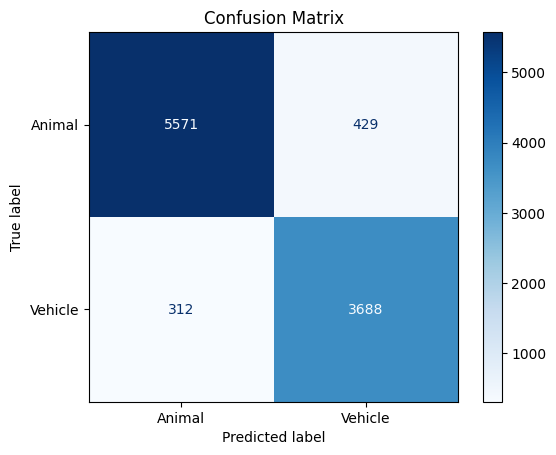

In [35]:
# Final Evaluation on Test Set
print("\nFinal Evaluation on Test Set")
print("="*70)

y_test_pred = svm_rbf.predict(x_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.2%}")
print("="*70)

# Detailed Classification Report
print("\n=================Classification Report=================")
print(classification_report(y_test, y_test_pred, target_names=['Animal', 'Vehicle']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Animal', 'Vehicle'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()